# Exercise 1: Home Value Estimation — California Housing

## Context

You've joined a small analytics team building a home-value estimation tool for California. Leadership wants a first-pass model before committing more resources, plus an honest read on how much to trust it.

## Data handed over

Census block groups from the 1990 U.S. Census, built into scikit-learn (`fetch_california_housing`). No download needed. Feature selection has already been done by the team: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, and location were judged relevant to home valuation before this data reached you. You don't need to go hunting for which raw signals matter. Whether this set is sufficient, or has more than it needs, is fair to revisit once you've seen how a first model performs.

- **MedInc**: median income in the block group (tens of thousands of USD)
- **HouseAge**: median house age
- **AveRooms** / **AveBedrms**: average rooms / bedrooms per household
- **Population**: block group population
- **AveOccup**: average household occupancy
- **Latitude** / **Longitude**: location

**Target: MedHouseVal.** Median house value for the block group, in hundreds of thousands of USD.

## Objective

Produce a first model, and report how good it actually is, including anything about the data itself that could make predictions misleading if ignored. No metric has been decided yet; that's part of the job.

## Approach

The approach for this module: get a simple baseline up fast, and let evidence from its own errors decide what happens next.

- **Model zero**: fit the simplest model on every available feature, as-is (feature selection is already done). Let its residuals drive what comes next, not speculation.
- A quick integrity check first: dtypes, missing values, and each variable's distribution, to rule out anything that would make the fit untrustworthy.
- Feature engineering and model comparisons come later, if the evidence calls for them.

## 1. Load the data and split before touching anything

We split into train and test first, before any EDA: exploring the full
dataset would mean treating all of it as training data, leaving nothing
held out to check whether conclusions generalize.

In [1]:
from sklearn.datasets        import fetch_california_housing
from sklearn.model_selection import train_test_split
import pandas as pd

housing = fetch_california_housing(as_frame=True)
df = housing.frame

X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

# set aside the test set now; it stays untouched until final evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"train: {X_train.shape}, test: {X_test.shape}")

train: (16512, 8), test: (4128, 8)


## 2. Sanity check before fitting anything

Integrity, not engineering: dtypes, missing values, and the distribution of every variable, target included. Looking for anything that would make a fit untrustworthy, not deciding transforms yet.

In [2]:
# training set only: never peek at X_test/y_test here
print(f"dtypes:\n{X_train.dtypes}")
print(f"\nmissing values (features): {int(X_train.isna().sum().sum())}")
print(f"missing values (target):   {int(y_train.isna().sum())}")
print(f"\nfeature summary:\n{X_train.describe()}")
print(f"\ntarget summary:\n{y_train.describe()}")

dtypes:
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
dtype: object

missing values (features): 0
missing values (target):   0

feature summary:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  16512.000000  16512.000000  16512.000000  16512.000000  16512.000000   
mean       3.880754     28.608285      5.435235      1.096685   1426.453004   
std        1.904294     12.602499      2.387375      0.433215   1137.056380   
min        0.499900      1.000000      0.888889      0.333333      3.000000   
25%        2.566700     18.000000      4.452055      1.006508    789.000000   
50%        3.545800     29.000000      5.235874      1.049286   1167.000000   
75%        4.773175     37.000000      6.061037      1.100348   1726.000000   
max       15.000100     52.000000    141.909091     25.636364  35682.000000   

           Av

No missing values, no dtype surprises. A few extremes already stand out:
`AveRooms` and `AveOccup`'s maximums are wildly out of line with their
medians, and the target caps out at exactly 5.00001, which looks like a
truncated maximum rather than a real one.

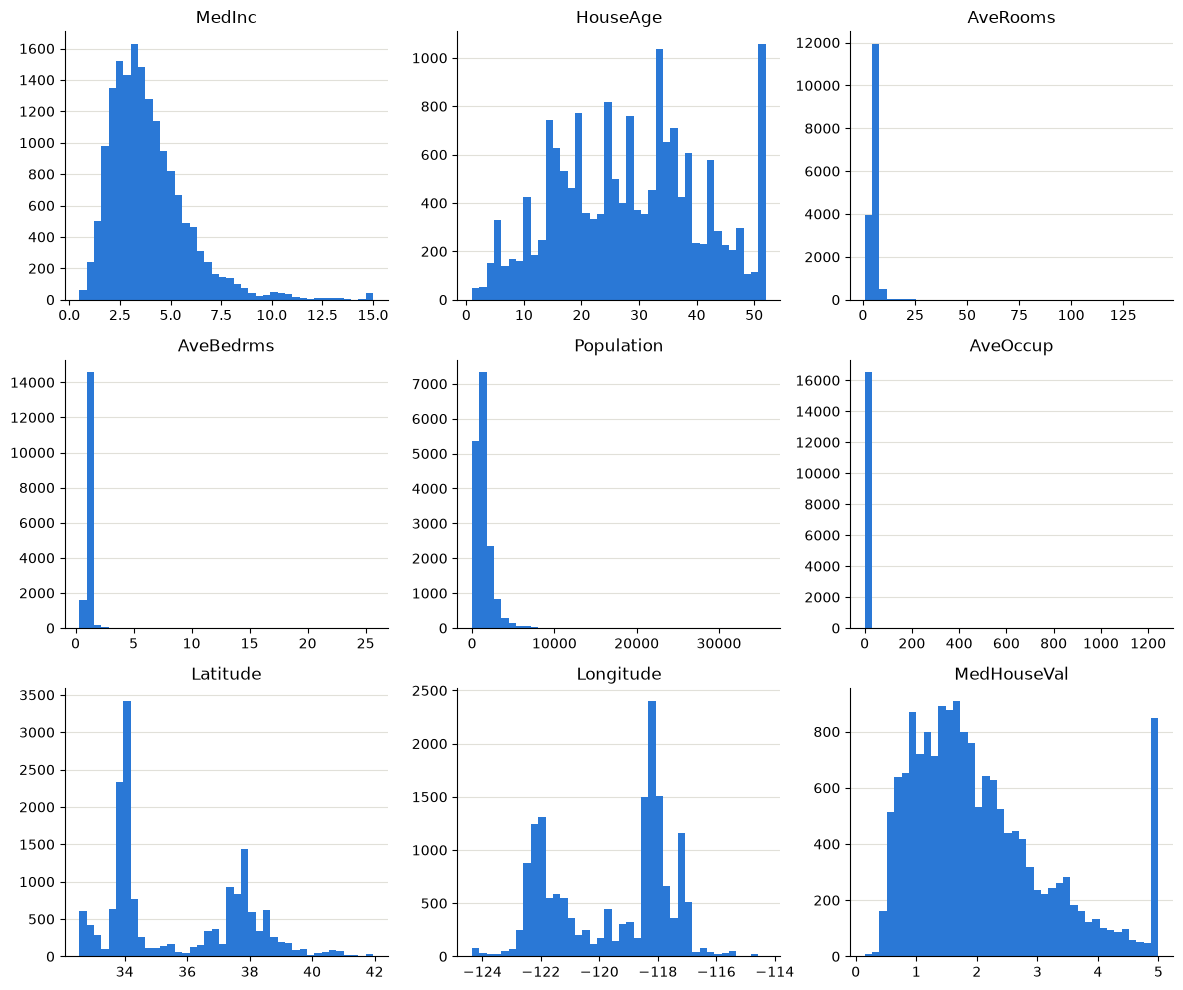

In [3]:
# quick visual pass: one histogram per feature, plus the target
import matplotlib.pyplot as plt

data = X_train.copy()
data["MedHouseVal"] = y_train

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for ax, col in zip(axes.flat, data.columns):
    ax.hist(data[col], bins=40, color="#2a78d6")
    ax.set_title(col)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)

plt.tight_layout()
plt.show()

The target's spike right at its maximum confirms a hard cutoff, not just a
high value. Several features (`AveRooms`, `AveBedrms`, `Population`,
`AveOccup`) are heavily right-skewed, with a handful of extreme outliers
driving their maximums. `HouseAge` shows that same spike-at-the-maximum
shape at its own cap of 52, hinting it may be capped the same way the
target is.

## 3. Trivial baseline: predict the mean

The floor any real model has to clear: with no other information,
predicting the mean minimizes squared error, so beating it by a wide margin
is the first real test.

In [4]:
import numpy as np

# predict the training-set mean for every row in the test set
naive_pred = np.full(shape=y_test.shape, fill_value=y_train.mean())
naive_residuals = naive_pred - y_test.values  # predicted - actual, in $100k units

print("naive baseline residuals (predicted - actual):")
print(pd.Series(naive_residuals).describe())

naive baseline residuals (predicted - actual):
count    4128.000000
mean        0.016944
std         1.144870
min        -2.928063
25%        -0.558053
50%         0.285447
75%         0.879197
max         1.921957
dtype: float64


## 4. Real baseline: plain linear regression on all raw features

No dropped columns, no transforms, no scaling (OLS doesn't need it: scaling only matters for regularized/gradient-descent-based fitting, which comes later). The point isn't a good score, it's a number to react to.

In [5]:
# fit on train, evaluate on test: the first legitimate use of X_test so far
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)
residuals = pred - y_test.values  # predicted - actual, in $100k units

print("baseline linear regression residuals (predicted - actual):")
print(pd.Series(residuals).describe())

baseline linear regression residuals (predicted - actual):
count    4128.000000
mean       -0.003479
std         0.745664
min        -4.148388
25%        -0.312442
50%         0.122439
75%         0.460935
max         9.875331
dtype: float64


## 5. Look at the actual error distribution before choosing how to report it

No metric committed to yet: just the raw residuals, side by side, for both baselines.

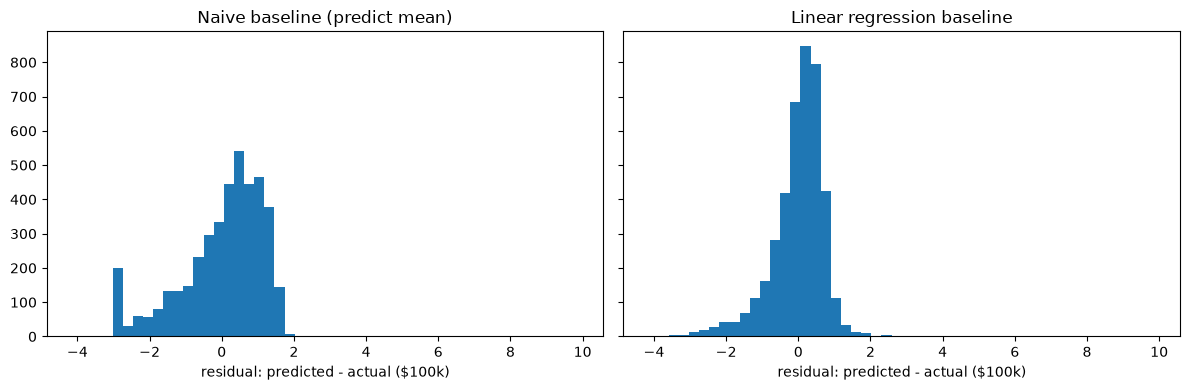

In [6]:
# compare both baselines' error distributions side by side; same bin range
# for both, so bar heights are actually comparable
shared_range = (min(naive_residuals.min(), residuals.min()),
                max(naive_residuals.max(), residuals.max()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

axes[0].hist(naive_residuals, bins=50, range=shared_range)
axes[0].set_title("Naive baseline (predict mean)")
axes[0].set_xlabel("residual: predicted - actual ($100k)")

axes[1].hist(residuals, bins=50, range=shared_range)
axes[1].set_title("Linear regression baseline")
axes[1].set_xlabel("residual: predicted - actual ($100k)")

plt.tight_layout()
plt.show()

Linear regression tightens the bulk of errors well: its spread (std 0.75) is
nearly half the naive baseline's (1.14). But its tail is far worse: a max
miss of +9.88 against the naive baseline's 1.92, and a min of -4.15 against
-2.93. Something specific is driving those extreme errors, not just general
noise, worth investigating before trusting any single average metric.

## 6. Investigating the heavy tail

Two candidate explanations to check: a hard cap on the target, and an extreme value in a feature that's itself a per-household ratio.

In [7]:
# (a) Target censoring: how much of the data sits exactly at the cap, and
# how biased is the model specifically on those points?
capped_mask = (y_test.values == y.max())
print(f"capped points in test set: {capped_mask.sum()} / {len(y_test)} ({capped_mask.mean():.1%})")
print(f"\nresiduals AT the cap:\n{pd.Series(residuals[capped_mask]).describe()}")
print(f"\nresiduals everywhere else:\n{pd.Series(residuals[~capped_mask]).describe()}")

capped points in test set: 179 / 4128 (4.3%)

residuals AT the cap:
count    179.000000
mean      -1.128152
std        1.379678
min       -4.148388
25%       -2.207698
50%       -1.190934
75%       -0.204870
max        2.260283
dtype: float64

residuals everywhere else:
count    3949.000000
mean        0.047500
std         0.659888
min        -3.632784
25%        -0.259281
50%         0.141655
75%         0.468142
max         9.875331
dtype: float64


Confirmed: 4.3% of the test set sits exactly at the cap, and residuals there
are biased sharply negative (mean -1.13, vs +0.05 everywhere else). The
model is predicting what it thinks the true value should be, often above
the cap, and gets penalized against a label that was truncated before
training ever saw it. A real, systematic effect, not noise.

In [8]:
# (b) The single worst prediction: is it a leverage-point effect from AveRooms/AveBedrms?
worst_idx = residuals.argmax()
print(f"predicted: {pred[worst_idx]:.3f}   actual: {y_test.values[worst_idx]:.3f}")
print("\nfeature values for this row, and where they rank against the training set:")
row = X_test.iloc[worst_idx]
for col in X_test.columns:
    pctile = (X_train[col] < row[col]).mean() * 100
    print(f"  {col:12s} = {row[col]:10.3f}   ({pctile:5.1f}th percentile)")

predicted: 11.500   actual: 1.625

feature values for this row, and where they rank against the training set:
  MedInc       =      4.625   ( 72.5th percentile)
  HouseAge     =     34.000   ( 62.0th percentile)
  AveRooms     =    132.533   (100.0th percentile)
  AveBedrms    =     34.067   (100.0th percentile)
  Population   =     36.000   (  0.3th percentile)
  AveOccup     =      2.400   ( 23.3th percentile)
  Latitude     =     38.800   ( 94.3th percentile)
  Longitude    =   -120.080   ( 39.7th percentile)


Confirmed, and distinct from the censoring effect above: the worst
prediction (actual 1.625, predicted 11.5) comes from a row where `AveRooms`
and `AveBedrms` both sit at the 100th percentile (132.5 and 34.1). Both are
per-household ratios, and this block group's own numbers show why: working
backward from `Population`/`AveOccup` gives about 15 households, implying
roughly 1,988 total rooms and 511 total bedrooms between them. A tiny
denominator turns an unremarkable total into an extreme ratio.

Two different problems, two different fixes: target censoring is a
data-handling decision (how we treat those rows), not a modeling one; the
leverage point is a feature/model decision, since plain linear regression is
specifically vulnerable to a long-tailed ratio feature pulling its fit. Both
get addressed before the next model, not by picking a fancier algorithm
blindly.